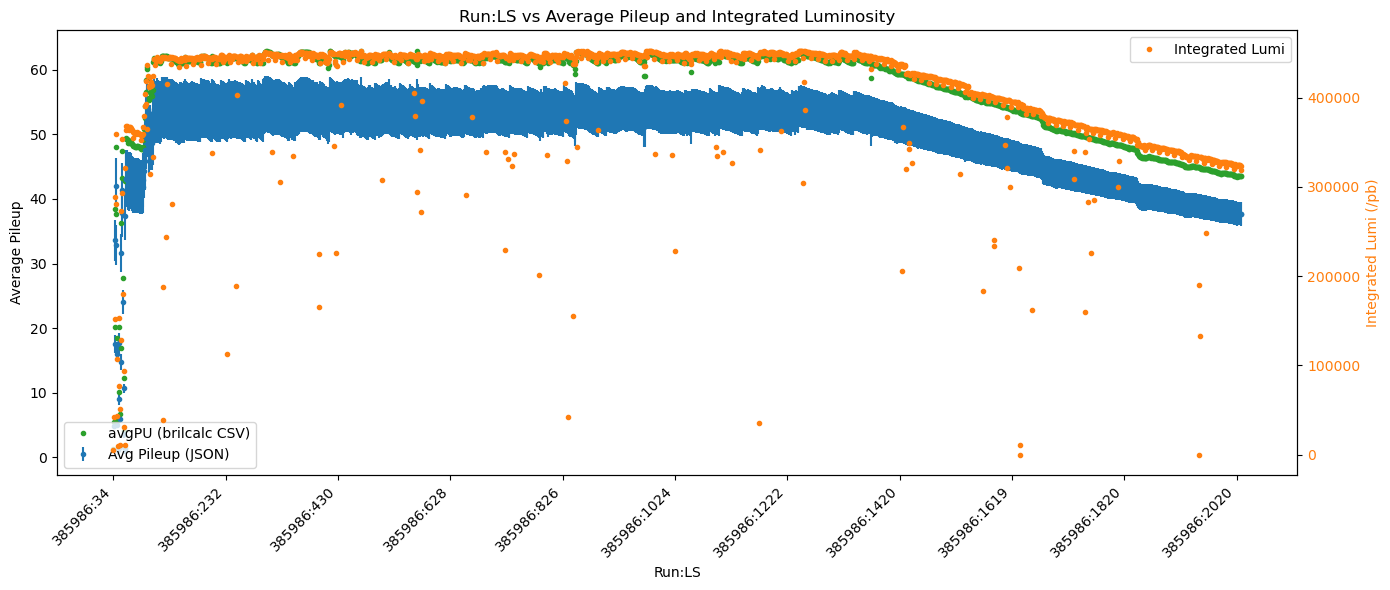

In [13]:
import json
import pandas as pd
import matplotlib.pyplot as plt

def read_lumi_data(lumi_file):
    """Read luminosity data from brilcalc CSV."""
    df = pd.read_csv(lumi_file, skiprows=1, engine='python', skipfooter=5, parse_dates=['time'])
    df[['run', 'fill']] = df['#run:fill'].str.split(':', expand=True)
    df = df.drop(columns=['#run:fill'])
    df = df[['run', 'fill', 'time', 'ls', 'beamstatus', 'recorded(/ub)', 'delivered(/ub)', 'avgpu']]
    df['run'] = df['run'].astype(int)
    df['ls'] = df['ls'].apply(lambda x: x.split(':')[0]).astype(int)
    return df

# Constants
scale_factor = 69200

# Load JSON pileup data
pileup_file = '../dataSubmit/ParkingDoubleMuonLowMass/2024/H0/crab_TTree_136TeV_PDMLM0_mm_2024H_Run385986/results/pileup_JSON.txt'
with open(pileup_file) as f:
    pileup_data = json.load(f)

# Load brilcalc CSV
lumi_file = '../preselection/parkingDoubleMuonLowMass/2024/lumi_normtagBRIL_PDMLM0_2024H_Run385986.csv'
lumi_df = read_lumi_data(lumi_file)

# Lists for plotting
labels = []
avg_pileup_json = []
rms_pileup_json = []
int_lumi = []
avg_pileup_csv = []

for run, entries in pileup_data.items():
    for entry in entries:
        ls = entry[0]
        lumi = entry[1]
        rms = entry[2] * scale_factor
        avg = entry[3] * scale_factor

        label = f"{run}:{ls}"
        labels.append(label)
        avg_pileup_json.append(avg)
        rms_pileup_json.append(rms)
        int_lumi.append(lumi)

        # Match CSV avgpu
        run_int = int(run)
        matching_row = lumi_df[(lumi_df['run'] == run_int) & (lumi_df['ls'] == ls)]
        if not matching_row.empty:
            avg_pileup_csv.append(matching_row.iloc[0]['avgpu'])
        else:
            avg_pileup_csv.append(None)  # could be NaN

# Create plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot average pileup (JSON)
ax1.errorbar(range(len(labels)), avg_pileup_json, yerr=rms_pileup_json, fmt='.', color='tab:blue', label="Avg Pileup (JSON)")
# Plot avgPU from CSV
ax1.plot(range(len(labels)), avg_pileup_csv, '.', color='tab:green', label="avgPU (brilcalc CSV)")
ax1.set_ylabel("Average Pileup", color='black')
ax1.set_xlabel("Run:LS")
ax1.tick_params(axis='y')
ax1.set_xticks(range(0, len(labels), max(1, len(labels)//10)))
ax1.set_xticklabels([labels[i] for i in range(0, len(labels), max(1, len(labels)//10))], rotation=45, ha='right')

# Secondary y-axis for integrated lumi
ax2 = ax1.twinx()
ax2.plot(range(len(labels)), int_lumi, '.', color='tab:orange', label="Integrated Lumi")
ax2.set_ylabel("Integrated Lumi (/pb)", color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Legends
ax1.legend(loc='lower left')
ax2.legend(loc='upper right')

# Title and layout
plt.title("Run:LS vs Average Pileup and Integrated Luminosity")
fig.tight_layout()
plt.show()
